# This notebook shows how to compute orbital-character (s, p, d, f) projection operators and apply them to wavefunctions
### Import the necessary libraries

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from elkpy.structure import Structure
from elkpy.session import ORBITAL_LABELS

### The $\ell$-resolved atom-projection operator
Splitting the atom-projection operator $P_\alpha$ (previous notebook) by angular momentum before summing over $m$ gives, for $\ell=0,1,2,3$ (s, p, d, f)
$$ (P_{\alpha,\ell})_{ij}=\sum_{m=-\ell}^{\ell}\sum_\sigma\int_0^{R_\alpha}\psi_{i,\ell m\sigma}^*(r)\,\psi_{j,\ell m\sigma}(r)\,r^2\,dr, \qquad \sum_{\ell=0}^3 P_{\alpha,\ell}\preceq P_\alpha $$
the familiar "orbital character" of a band -- how much of a state's weight on atom $\alpha$ has s/p/d/f symmetry -- generalized here to an off-diagonal operator applicable to any wavefunction, not just a per-state weight table.

In [2]:
SI_AVEC = [(5.13, 5.13, 0.00), (5.13, 0.00, 5.13), (0.00, 5.13, 5.13)]
SI_SPECIES = {"Si": [(0.0, 0.0, 0.0), (0.25, 0.25, 0.25)]}
si = Structure(SI_AVEC, SI_SPECIES).get_calculation("_scratch/si_orbitalproj", xc="PW", ngridk=(4, 4, 4))

orb = si.get_orbital_projection((0.1, 0.2, 0.05), ist0=1, ist1=4)
orb.matrices.shape  # (natmtot, 4, nst, nst) -- l axis order given by ORBITAL_LABELS

(2, 4, 4, 4)

### s+p+d+f falls short of the full atom-projection weight
The muffin-tin basis extends beyond $\ell=3$ (Elk's own default cutoff is $\ell_{\rm max}=6$), so summing only s,p,d,f can never exceed `get_atom_projection()`'s full per-atom weight -- the remainder (g,h,i character) must be Hermitian and positive semi-definite.

In [3]:
proj = si.get_atom_projection((0.1, 0.2, 0.05), ist0=1, ist1=4)
spdf_sum = orb.matrices.sum(axis=1)  # sum over l -> (natmtot, nst, nst)
remainder = proj.matrices - spdf_sum

herm_err = np.abs(remainder - remainder.conj().transpose(0, 2, 1)).max()
print("Hermitian (max |P - P^dagger|):", herm_err)
print("eigenvalues of the g/h/i remainder (all >= 0):")
for a in range(remainder.shape[0]):
    print(" atom", a, np.linalg.eigvalsh(remainder[a]).round(4))

Hermitian (max |P - P^dagger|): 2.797236311097076e-17
eigenvalues of the g/h/i remainder (all >= 0):
 atom 0 [0.0001 0.0002 0.0002 0.0003]
 atom 1 [0.0001 0.0002 0.0002 0.0003]


### Orbital character across bands: monolayer h-BN
The occupied valence-top ($\pi$) band at K is a nitrogen $2p_z$ state; a much deeper bonding ($\sigma$-type) valence band is nitrogen $2s$-dominated instead -- the dominant channel flips between the two bands of the *same* atom.

In [4]:
import re

A, VACUUM = 4.743210000, 20.0  # Bohr, same hBN slab as 05_berry_curvature.ipynb
HBN_AVEC = [(A, 0.0, 0.0), (-A / 2, A * 3 ** 0.5 / 2, 0.0), (0.0, 0.0, VACUUM)]
HBN_SPECIES = {"B": [(1 / 3, 2 / 3, 0.5)], "N": [(2 / 3, 1 / 3, 0.5)]}

hbn = Structure(HBN_AVEC, HBN_SPECIES).get_calculation("_scratch/hbn_orbitalproj", xc="PW", ngridk=(6, 6, 1), rgkmax=7.0)
hbn.get_energy()

first_block = (hbn.workdir / "EIGVAL.OUT").read_text().split("k-point")[1]
state_line = re.compile(r"^\s*\d+\s+(\S+)\s+(\S+)\s*$")
occ = [float(m.group(2)) for m in map(state_line.match, first_block.splitlines()) if m]
ist1 = sum(o > 1.0 for o in occ)  # index (1-based) of the valence-top band
ist1

4

In [5]:
K = (1 / 3, 1 / 3, 0)
n = hbn.structure.atom_index("N")

orb_top = hbn.get_orbital_projection(K, ist0=ist1, ist1=ist1)       # valence-top (pi) band
orb_deep = hbn.get_orbital_projection(K, ist0=1, ist1=1)            # deep bonding (sigma) band

weights = {
    "valence top ($\\pi$)": orb_top.matrices[n, :, 0, 0].real,
    "deep bonding ($\\sigma$)": orb_deep.matrices[n, :, 0, 0].real,
}
weights

{'valence top ($\\pi$)': array([8.84783545e-32, 5.21834841e-01, 2.36135279e-14, 2.71958895e-05]),
 'deep bonding ($\\sigma$)': array([5.34068992e-01, 1.28353003e-12, 5.12915831e-04, 3.60163166e-04])}

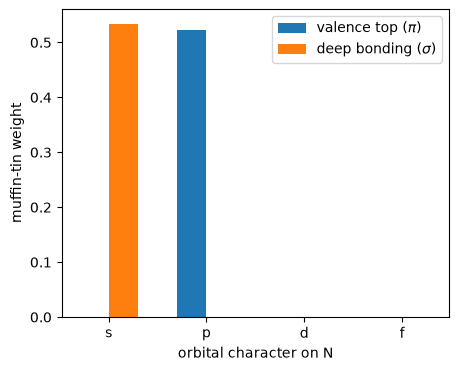

In [6]:
x = np.arange(len(ORBITAL_LABELS))
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(x - 0.15, weights["valence top ($\\pi$)"], width=0.3, label="valence top ($\\pi$)")
ax.bar(x + 0.15, weights["deep bonding ($\\sigma$)"], width=0.3, label="deep bonding ($\\sigma$)")
ax.set_xticks(x)
ax.set_xticklabels(ORBITAL_LABELS)
ax.set_xlabel("orbital character on N")
ax.set_ylabel("muffin-tin weight")
ax.legend()
plt.show()